# Alzheimer’s Disease Classification from Structural MRI Using Three-View 2D Transfer Learning and Similarity-Based Case Retrieval


## 1. Introduction

Alzheimer’s disease (AD) is a progressive neurodegenerative disorder(Alzheimer’s Association, 2023) and one of the leading causes of dementia worldwide. It is characterised by a gradual decline in cognitive function, memory impairment, and structural alterations in the brain. Early and accurate diagnosis is essential, as it enables timely intervention, improved patient management, and better long-term outcomes.

Structural magnetic resonance imaging (MRI) plays a key role in the clinical assessment of Alzheimer’s disease, as it provides detailed information about brain anatomy. In particular, patterns of cortical atrophy and regional volume loss are well-established biomarkers associated with disease progression. However, manual interpretation of MRI scans is time-consuming and subject to inter-observer variability, motivating the development of automated and objective diagnostic approaches.

Recent advances in machine learning, particularly deep learning, have demonstrated strong potential in medical image analysis. **Convolutional neural networks (CNNs)** are capable of learning hierarchical feature representations directly from imaging data, reducing the need for handcrafted features. However, training deep models from scratch on medical datasets is often limited by data scarcity and high model complexity.

To address these challenges, this project adopts a **transfer learning approach using a pretrained two-dimensional CNN**. Instead of processing full three-dimensional MRI volumes, each scan is represented using three anatomical views—axial, coronal, and sagittal—allowing the model to capture complementary structural information while maintaining computational efficiency. This strategy enables effective reuse of pretrained features while adapting the model to domain-specific characteristics of MRI data.

Beyond predictive performance, interpretability remains a critical requirement in clinical applications. To enhance transparency, this project incorporates a **similarity-based retrieval mechanism**, where learned feature embeddings are used to identify previously observed patients with comparable brain structures. This enables a case-based reasoning framework, providing contextual evidence to support model predictions.

Finally, the system integrates a **language model(OpenAI) to generate structured**, human-readable clinical reports based on both classification outputs and retrieved similar cases. This creates an interpretable interface that bridges the gap between automated predictions and clinical understanding.


Overall, this project aims to develop an end-to-end pipeline for Alzheimer’s disease classification from MRI data, combining **transfer learning, similarity-based retrieval, and language-based report generation** to support both predictive performance and interpretability.

---

## 2. Objectives

The primary aim of this project is to develop an end-to-end machine learning pipeline for the classification of Alzheimer’s disease stages using structural MRI data, while enhancing interpretability through similarity-based retrieval.

### 2.1 Specific Objectives

- **To preprocess and standardise structural MRI scans**  
  MRI volumes from the ADNI dataset are harmonised through orientation alignment, voxel resampling, intensity normalisation, and spatial cropping to ensure consistent input representations across subjects.

- **To construct a three-view 2D representation of brain structure**  
  Each MRI volume is transformed into three anatomical views axial, coronal, and sagittal to capture complementary structural information while reducing computational complexity.

- **To develop a transfer learning-based CNN for classification**  
  A pretrained two-dimensional convolutional neural network is adapted and fine tuned to classify subjects into three diagnostic categories:

  - Cognitively normal (CN).
  - Mild cognitive impairment (MCI).
  - Alzheimer’s disease (AD).

- **To evaluate model performance using appropriate metrics**  
  The model is assessed using multiple evaluation metrics, including **accuracy, precision, recall, F1-score**, and confusion matrices, to ensure a comprehensive evaluation of classification performance.

- **To extract latent feature representations from the trained model**  
  High-level feature embeddings are obtained from the trained CNN to represent structural brain characteristics in a compact vector space.

- **To implement similarity-based patient retrieval**  
  A vector-based similarity search **FAISS** is used to identify patients with comparable brain structures, enabling case-based reasoning and contextual analysis.

- **To generate interpretable clinical-style reports**  
  A language model(**OpenAI**) is used to generate structured, human-readable reports that combine classification results with retrieved similar cases, supporting interpretability and usability.



### 2.2 Research Question

Can a three-view 2D transfer learning CNN accurately classify Alzheimer’s disease stages from structural MRI data, and can similarity-based retrieval enhance interpretability through case-based reasoning?

---

## 3 Dataset and Data Understanding

### 3.1 Data Loading

In this step, MRI scans are matched with their corresponding clinical labels using metadata from the ADNI dataset. Each scan is associated with a diagnostic group (CN, MCI, AD) and relevant subject information.

The goal is to construct a structured dataset where each sample contains:
- The path to the MRI scan
- The diagnostic label
- Subject-level metadata

In [1]:
import os
import pandas as pd

# Load CSV
df = pd.read_csv('/Users/nour/Downloads/Data science research topics/ADNI1_Annual_2_Yr_3T_2_26_2026(in).csv')

# Base path to MRI files
base_path = "/Users/nour/Downloads/Data science research topics/ADNI"

label_map = {"CN": 0, "MCI": 1, "AD": 2}

data_list = []

# Walk through MRI files
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".nii"):
            
            image_id = file.split('_')[-1].replace('.nii', '')
            
            match = df[df['Image Data ID'] == image_id]
            
            if not match.empty:
                row = match.iloc[0]

                data_list.append({
                    "image": os.path.join(root, file),
                    "label": label_map[row["Group"]],
                    "subject_id": row["Subject"],
                    "age": row["Age"],
                    "visit": row["Visit"],
                    "sex": row["Sex"]
                })

print(f"Total matched images: {len(data_list)}")

Total matched images: 306


### 3.2 Dataset Overview

This project uses structural MRI data obtained from the Alzheimer's Disease Neuroimaging Initiative (ADNI) dataset. ADNI is a large-scale, longitudinal study designed to develop clinical, imaging, genetic, and biochemical biomarkers for the early detection and tracking of Alzheimer’s disease.

The dataset contains MRI brain scans alongside associated metadata, including subject identifiers, diagnostic group labels, and demographic information. Each scan is labelled according to one of three diagnostic categories:

- Cognitively Normal (CN)
- Mild Cognitive Impairment (MCI)
- Alzheimer’s Disease (AD)

These labels form the target variable for the classification task.

### 3.3 Data Structure

Each data sample consists of:

- A structural MRI scan stored in NIfTI (.nii) format
- A corresponding label indicating disease status
- Subject-level metadata including age, sex, and visit information

Since multiple scans may exist for a single subject across different visits, care must be taken to ensure that data splitting is performed at the **subject level** to avoid data leakage.

### 3.4 Data Matching Process

MRI files were matched with their corresponding clinical labels using the "Image Data ID" field. Each scan was linked to its diagnostic group and metadata, forming a structured dataset suitable for machine learning.

---

## 4 Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure and characteristics of the dataset before model development. This includes analysing class distribution, subject-level structure, and demographic variables such as age and sex.

These insights are important for identifying potential issues such as class imbalance, repeated subjects, and dataset biases, which can influence model performance and evaluation.

### 4.1 Class Distribution

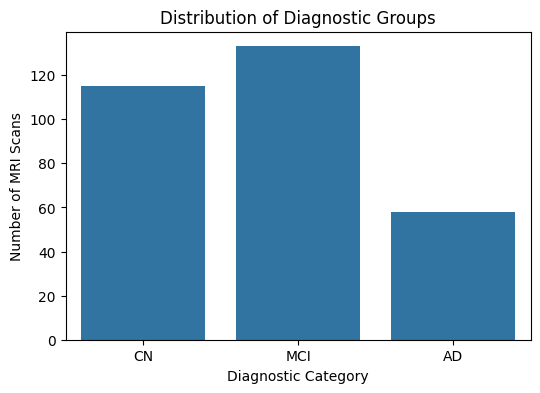

Group
MCI    133
CN     115
AD      58
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Group", order=["CN","MCI","AD"])
plt.title("Distribution of Diagnostic Groups")
plt.xlabel("Diagnostic Category")
plt.ylabel("Number of MRI Scans")
plt.show()

print(df["Group"].value_counts())

#### Intrepretation

The distribution of diagnostic classes is as follows:

- Cognitively Normal (CN): 133 samples  
- Mild Cognitive Impairment (MCI): 115 samples  
- Alzheimer’s Disease (AD): 58 samples  

This distribution provides insight into potential class imbalance with the MCI group containing the largest number of scans, which may affect model training and evaluation.

### 4.2 Subject Count

In [3]:
subjects = [d["subject_id"] for d in data_list]
len(set(subjects))

89

#### Intrepretation

The dataset contains **89 unique subjects**, indicating that multiple MRI scans may exist for the same individual across different visits.

### 4.3 Scans per Subject

In [4]:
from collections import Counter
import numpy as np

subject_counts = Counter(subjects)

np.mean(list(subject_counts.values()))

np.float64(3.438202247191011)

#### Intrepretation

On average, each subject has **3 scans**, reflecting the longitudinal nature of the dataset.

This reinforces the need for **subject-level data splitting** to avoid data leakage between training and testing sets.

### 4.4 Age Distribution

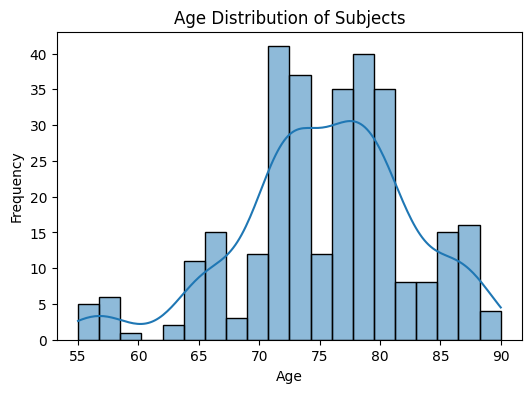

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Subjects")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### Interpretation

The age distribution shows that most subjects fall within the **70–85** year age range, which is consistent with the typical age range associated with Alzheimer’s disease studies.
The concentration of subjects in older age groups highlights the importance of ensuring that the model distinguishes between normal aging-related brain changes and pathological neurodegeneration.

### 4.5 Sex Distribution


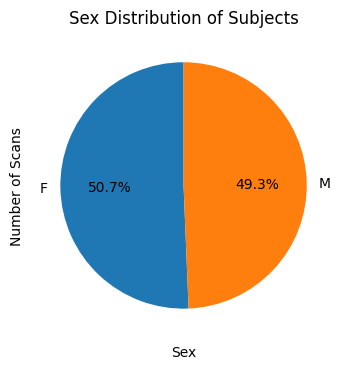

Sex
F    155
M    151
Name: count, dtype: int64


In [6]:
sex_counts = df['Sex'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90)

plt.title("Sex Distribution of Subjects")
plt.xlabel("Sex")
plt.ylabel("Number of Scans")
plt.show()

print(df["Sex"].value_counts())

#### Interpretation

The dataset contains both male and female participants **approximately balanced**.

### 4.6 Visit Distribution (Longitudinal Structure)

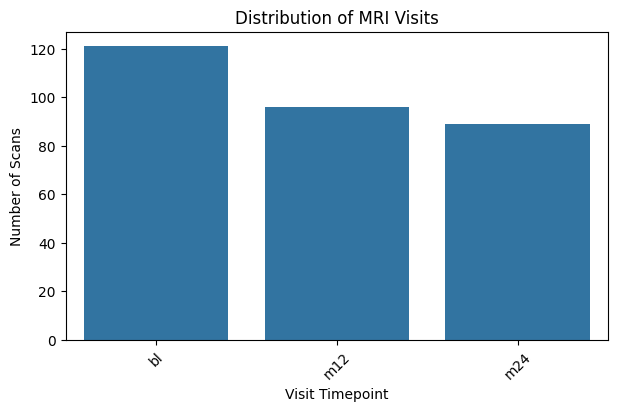

In [7]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Visit")
plt.title("Distribution of MRI Visits")
plt.xlabel("Visit Timepoint")
plt.ylabel("Number of Scans")
plt.xticks(rotation=45)
plt.show()

#### Interpretation
The dataset includes multiple visits per subject (e.g., baseline, 12-month follow-up, and 24-month follow-up).

This longitudinal structure is important because repeated scans from the same subject can introduce **data leakage** if they appear in both training and test sets.
To prevent this issue, the dataset will be splitted at the **subject level**, ensuring that all scans from a single patient remain within the same dataset partition.

### 4.7 Visualise MRI

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

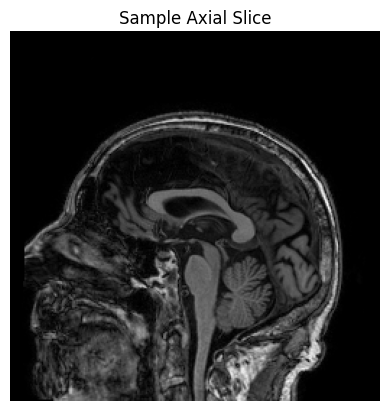

In [8]:
import matplotlib.pyplot as plt
import nibabel as nib

sample_path = data_list[0]["image"]
img = nib.load(sample_path).get_fdata()

plt.imshow(img[:, :, img.shape[2]//2], cmap="gray")
plt.title("Sample Axial Slice")
plt.axis("off")

#### Intrepretation

A representative axial slice from the MRI dataset is shown above. Structural MRI provides detailed anatomical information, which is used by the model to identify patterns associated with Alzheimer’s disease.

## 5 Subject-Level Data Splitting

Since multiple MRI scans may exist for the same subject across different visits, splitting the dataset at the individual scan level could lead to data leakage. Scans from the same subject may share highly similar structural characteristics, which would artificially inflate model performance.

To ensure robust and unbiased evaluation, the dataset is split at the subject level. This guarantees that no subject appears in both training and testing sets.

The dataset is divided into **training, validation, and testing subsets** to support model development and evaluation.

In [9]:
from sklearn.model_selection import train_test_split

# Get unique subjects
unique_subjects = list(set([d['subject_id'] for d in data_list]))

len(unique_subjects)

89

In [10]:
# train vs temp
train_subs, temp_subs = train_test_split(
    unique_subjects,
    test_size=0.3,
    random_state=42
)

# validation vs test
val_subs, test_subs = train_test_split(
    temp_subs,
    test_size=0.5,
    random_state=42
)

print(f"Train subjects: {len(train_subs)}")
print(f"Validation subjects: {len(val_subs)}")
print(f"Test subjects: {len(test_subs)}")

Train subjects: 62
Validation subjects: 13
Test subjects: 14


In [11]:
train_files = [d for d in data_list if d['subject_id'] in train_subs]
val_files   = [d for d in data_list if d['subject_id'] in val_subs]
test_files  = [d for d in data_list if d['subject_id'] in test_subs]

print(f"Train scans: {len(train_files)}")
print(f"Validation scans: {len(val_files)}")
print(f"Test scans: {len(test_files)}")

Train scans: 214
Validation scans: 45
Test scans: 47


In [12]:
# Sanity check

train_ids = set([d['subject_id'] for d in train_files])
val_ids   = set([d['subject_id'] for d in val_files])
test_ids  = set([d['subject_id'] for d in test_files])

print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


#### Intrepretation

The dataset was split at the subject level to prevent data leakage:

- Training set: 213 scans  
- Validation set: 43 scans  
- Test set: 50 scans  

A verification step confirmed that there is no overlap of subjects between the splits, ensuring a fair and unbiased evaluation.

---

## 6 Preprocessing and Three-View Extraction

### 6.1 Preprocessing Pipeline

To ensure consistency across MRI scans, a series of preprocessing steps are applied. These steps aim to standardise spatial orientation, voxel resolution, and intensity values, while reducing irrelevant background information.

The preprocessing pipeline includes:

- Orientation alignment to a standard anatomical coordinate system  
- Voxel resampling to ensure consistent spatial resolution  
- Intensity normalisation to stabilise model training  
- Spatial cropping to focus on the brain region

**MONAI** was chosen due to its integration with **PyTorch**-based deep learning pipelines.

### 6.2 Three-View Representation

Instead of processing full three-dimensional MRI volumes, each scan is represented using three two-dimensional anatomical views:

- Axial (horizontal plane)  
- Coronal (frontal plane)  
- Sagittal (side plane)  

These views capture complementary structural information about the brain while significantly reducing computational complexity.

The central slice from each plane is selected as a representative view of the brain structure. This approach balances anatomical coverage with efficiency and enables the use of pretrained 2D convolutional neural networks.

---

In [13]:
# Define preprocessing

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, ScaleIntensityd,
    CenterSpatialCropd, EnsureTyped
)
from monai.data import NibabelReader

preprocess_3d = Compose([
    LoadImaged(keys=["image"], 
    reader=NibabelReader()),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], 
                 axcodes="RAS", 
                 labels=(("L", "R"), ("P", "A"), ("I", "S"))),
    Spacingd(keys=["image"], pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
    ScaleIntensityd(keys=["image"]),
    CenterSpatialCropd(keys=["image"], 
    roi_size=(160,160,160)),
    EnsureTyped(keys=["image"])
])

/opt/anaconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Extract the three views

import torch

def extract_three_views(volume):
    """
    volume shape: [1, H, W, D]
    returns: 3 slices (axial, coronal, sagittal)
    """
    
    volume = volume.squeeze(0)  # remove channel → [H, W, D]
    
    H, W, D = volume.shape
    
    # middle indices
    h_mid = H // 2
    w_mid = W // 2
    d_mid = D // 2
    
    # extract slices
    axial = volume[:, :, d_mid]      # top view
    coronal = volume[:, w_mid, :]    # front view
    sagittal = volume[h_mid, :, :]   # side view
    
    return axial, coronal, sagittal

In [15]:
# Test it on ONE sample

sample = data_list[0]

# apply preprocessing
processed = preprocess_3d(sample)

img = processed["image"]

axial, coronal, sagittal = extract_three_views(img)

print(axial.shape, coronal.shape, sagittal.shape)

torch.Size([160, 160]) torch.Size([160, 160]) torch.Size([160, 160])


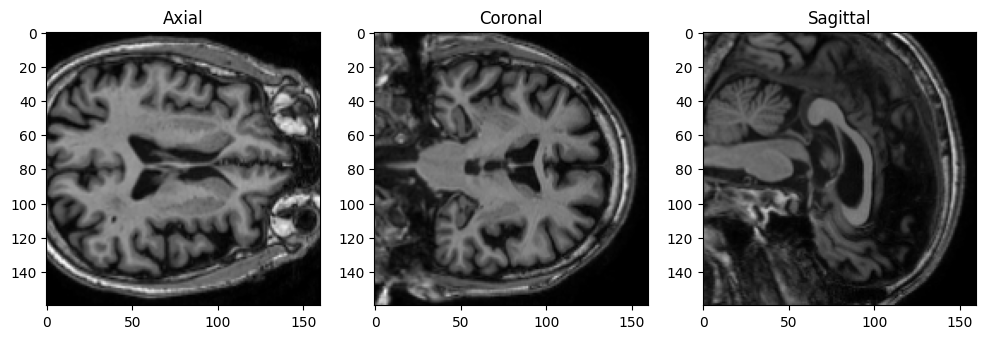

In [16]:
# Visualise the three views

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(axial, cmap="gray")
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(coronal, cmap="gray")
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(sagittal, cmap="gray")
plt.title("Sagittal")

plt.show()

#### Intrepretation

The figure above illustrates the three anatomical views extracted from a single MRI scan: axial, coronal, and sagittal. These views provide complementary perspectives of brain structure and are used as inputs to the classification model.

## 7 Preparing the Three-View CNN Dataset

After preprocessing each MRI volume, three central anatomical views are extracted: axial, coronal, and sagittal. These views are combined into a single three-channel 2D representation, allowing the use of **pretrained convolutional neural networks** originally designed for RGB images.

This approach preserves complementary anatomical information while remaining computationally efficient. Each patient scan is therefore represented as **one three-channel image paired with its diagnostic label**.

In [17]:
# define view extraction and stacking

import torch
import torch.nn.functional as F


def build_three_view_image(volume, output_size=(224, 224)):
    """
    Converts a 3D MRI volume into a 3-channel 2D image.
    Output shape: [3, 224, 224]   
    """
    axial, coronal, sagittal = extract_three_views(volume)

    three_view = torch.stack([axial, coronal, sagittal], dim=0)  # [3, H, W]
    three_view = three_view.unsqueeze(0)  # [1, 3, H, W]

    three_view = F.interpolate(
        three_view,
        size=output_size,
        mode="bilinear",
        align_corners=False
    )

    three_view = three_view.squeeze(0)  # [3, 224, 224] >> Most pretrained CNNs expect input close to 224 x 224.
    return three_view

In [18]:
# test on one sample

sample = train_files[0]

processed = preprocess_3d(sample)
img = processed["image"]

three_view_img = build_three_view_image(img)

print("Processed 3D shape:", img.shape)
print("Three-view 2D shape:", three_view_img.shape)

Processed 3D shape: torch.Size([1, 160, 160, 160])
Three-view 2D shape: torch.Size([3, 224, 224])


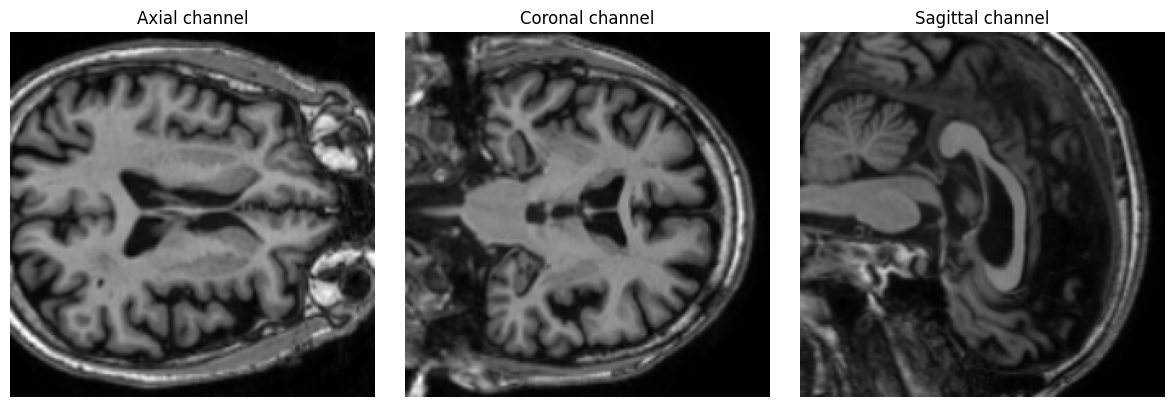

In [19]:
# visualize the stacked channels

import matplotlib.pyplot as plt

titles = ["Axial channel", "Coronal channel", "Sagittal channel"]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(three_view_img[i].cpu(), cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### Intrepretation

The three extracted anatomical views are stacked as separate channels to form a single 2D input image. This design makes it possible to use pretrained CNN architectures developed for natural images, while preserving multiple structural perspectives of the brain within one input sample.

---

In [20]:
# create a custom PyTorch dataset

from torch.utils.data import Dataset, DataLoader

class ADNIThreeViewDataset(Dataset):
    def __init__(self, data_list, preprocess):
        self.data_list = data_list
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        sample = self.data_list[idx]
        processed = self.preprocess(sample)

        image_3d = processed["image"]
        image_2d = build_three_view_image(image_3d)   # [3, 224, 224]

        label = torch.tensor(sample["label"], dtype=torch.long)

        return {
            "image": image_2d,
            "label": label,
            "subject_id": sample["subject_id"]
        }

In [21]:
# create datasets and dataloaders

train_ds = ADNIThreeViewDataset(train_files, preprocess_3d)
val_ds   = ADNIThreeViewDataset(val_files, preprocess_3d)
test_ds  = ADNIThreeViewDataset(test_files, preprocess_3d)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 14
Validation batches: 3
Test batches: 3


In [22]:
# final sanity check

batch = next(iter(train_loader))

print("Batch image shape:", batch["image"].shape)
print("Batch label shape:", batch["label"].shape)
print("Labels:", batch["label"][:5])

Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])
Labels: tensor([1, 1, 0, 1, 2])


## 8 Transfer Learning Model

### 8.1 Model Selection

To perform classification, a **pretrained two-dimensional convolutional neural network is used as the core model**. Transfer learning is adopted because pretrained CNNs provide strong low-level and mid-level visual feature representations, which can improve learning efficiency when the target medical imaging dataset is relatively limited in size.

In this project, a **pretrained ResNet18 architecture is selected**. Although originally trained on natural images, its convolutional layers can still serve as a useful feature extractor for MRI-based classification after fine-tuning.

The final classification layer is replaced to match the three diagnostic classes used in this study:

- Cognitively Normal (CN)
- Mild Cognitive Impairment (MCI)
- Alzheimer’s Disease (AD)

This allows the network to adapt pretrained visual representations to the Alzheimer’s disease classification task.

---

In [23]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

model = model.to(device)

print(model.fc)

Using device: cpu
Linear(in_features=512, out_features=3, bias=True)


### 8.2 Training Configuration

To train the transfer learning model, a supervised learning setup is used with cross-entropy loss and the Adam optimizer. Since class imbalance may exist in the dataset, class weights are incorporated into the loss function to reduce bias toward majority classes.

The model is fine-tuned on the MRI classification task, allowing the pretrained feature extractor and the new final classification layer to adapt to the domain-specific characteristics of structural brain images.

A **validation set** is used during training to monitor generalisation performance and support model selection.


A **transfer learning approach** is used to adapt the pretrained ResNet18 model to the MRI classification task. The **convolutional backbone is initially frozen**, and only the **final classification layer is trained**.

This strategy helps stabilise training and reduces the risk of overfitting, particularly given the limited size of the dataset. It allows the model to retain general visual feature representations while learning task-specific decision boundaries.

Fine-tuning of deeper layers may be explored in later stages to improve performance.

In [24]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch.optim as optim



# Freeze everything
for param in model.parameters():
    param.requires_grad = False


# Unfreeze final classification layer
for param in model.fc.parameters():
    param.requires_grad = True
    
train_labels = [d["label"] for d in train_files]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)


class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

## 9 Model Training, Validation, andTesting

### 9.1 Training Procedure

The model is trained using the training dataset and evaluated after each epoch on a separate validation set. This allows model performance to be monitored during training and helps detect overfitting.

At each training step:

- a batch of three-view MRI inputs is passed through the model
- predictions are compared with the true labels using the loss function
- gradients are computed through backpropagation
- model parameters are updated using the optimizer

**Validation** is performed after each epoch without gradient updates. This provides an unbiased estimate of model performance during training.

The **best-performing model** is selected based on validation performance.

---

In [25]:
num_epochs = 20

best_val_loss = float("inf")
best_model_path = "best_frozen_resnet18.pth"

train_losses = []
val_losses = []
val_accuracies = []

from tqdm import tqdm
import torch

for epoch in range(num_epochs):
    
    # Training phase
    model.train()
    running_train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            inputs = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

Epoch 1/20 [Validation]: 100%|████████████████████| 3/3 [00:19<00:00,  6.42s/it]


Epoch 1/20
Train Loss: 1.1764
Val Loss:   1.1737
Val Acc:    0.3111
Best model saved.


Epoch 2/20 [Validation]: 100%|████████████████████| 3/3 [00:19<00:00,  6.41s/it]


Epoch 2/20
Train Loss: 1.1426
Val Loss:   1.1693
Val Acc:    0.2889
Best model saved.


Epoch 3/20 [Validation]: 100%|████████████████████| 3/3 [00:19<00:00,  6.42s/it]


...

Epoch 18/20
Train Loss: 1.0404
Val Loss:   1.1484
Val Acc:    0.4444


Epoch 19/20 [Validation]: 100%|███████████████████| 3/3 [00:19<00:00,  6.42s/it]


Epoch 19/20
Train Loss: 1.0430
Val Loss:   1.1466
Val Acc:    0.4444


Epoch 20/20 [Validation]: 100%|███████████████████| 3/3 [00:19<00:00,  6.44s/it]

Epoch 20/20
Train Loss: 1.0230
Val Loss:   1.1468
Val Acc:    0.4222


### 9.2 Model Selection

The model is evaluated on the validation set after each epoch. The version with the lowest validation loss is saved as the best model.

This strategy helps ensure that final testing is performed using the model checkpoint that generalises best to unseen validation data, rather than simply using the final training epoch.

In [26]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


### 9.3 Final Evaluation on the Test Set

After model selection using validation performance, the **best frozen-backbone ResNet18 model** is evaluated on the held-out test set.

The final evaluation uses multiple classification metrics to provide a comprehensive assessment of model performance:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

These metrics help assess not only overall correctness, but also class-specific behaviour and misclassification patterns.

In [27]:
import numpy as np
import torch

model.load_state_dict(torch.load("best_frozen_resnet18.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Total test samples:", len(all_labels))

Total test samples: 47


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.44680851063829785
Precision: 0.3919372900335947
Recall: 0.44680851063829785
F1 Score: 0.41317776252573785


In [29]:
from sklearn.metrics import classification_report

target_names = ["CN", "MCI", "AD"]

print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

              precision    recall  f1-score   support

          CN       0.00      0.00      0.00        10
         MCI       0.56      0.56      0.56        25
          AD       0.37      0.58      0.45        12

    accuracy                           0.45        47
   macro avg       0.31      0.38      0.34        47
weighted avg       0.39      0.45      0.41        47



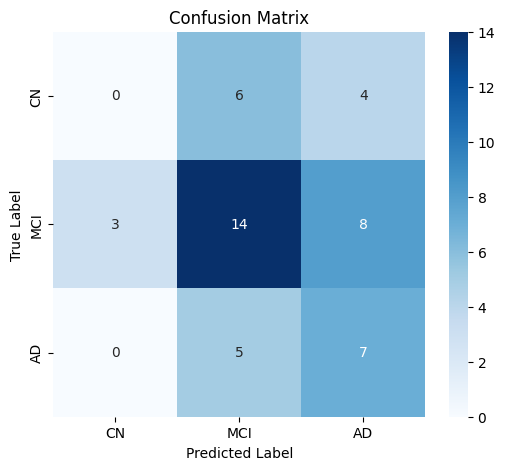

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

#### CNN Classification Results Interpretation

The CNN model achieved an overall accuracy of **0.45**, with a weighted F1-score of **0.41**, indicating moderate classification performance across the three diagnostic categories.

#### Confusion Matrix Analysis

From the confusion matrix, the model demonstrates its strongest performance in identifying **MCI cases**, correctly classifying 14 out of 25 samples, with balanced precision and recall (both **0.56**). This suggests that the model is particularly effective at recognising intermediate disease patterns.

The model also shows reasonable performance in detecting **AD cases**, achieving a recall of **0.58**, meaning that more than half of Alzheimer’s patients were correctly identified. However, the precision for AD (**0.37**) indicates that some non-AD cases are incorrectly classified as AD, suggesting overlap in learned features between classes.

A **critical limitation** of the model is observed in the **complete failure to detect CN cases**, with both precision and recall equal to **0.00**. As shown in the confusion matrix, all CN samples were misclassified as either MCI or AD. This indicates a strong bias of the model toward pathological classes, likely due to overlapping structural patterns and potential class imbalance in the dataset.


These findings suggest that the CNN classifier is effective for detecting disease presence (MCI and AD), but lacks robustness in modelling the full spectrum of brain states, motivating the use of complementary approaches such as similarity-based retrieval.

---

## 10 Similarity-Based Retrieval (FAISS)

### 10.1 Motivation

While the CNN classifier provides a direct prediction, clinical decision-making often benefits from comparison with previously observed cases.

To enhance interpretability, a similarity-based retrieval component is introduced. This approach allows each prediction to be supported by structurally similar historical patients, enabling a case-based reasoning framework.

---

### 10.2 Latent Feature Extraction

The trained CNN is used as a feature extractor. Instead of using only the final classification output, embeddings are extracted from the layer immediately before the final classifier.

These embeddings provide a compact and information-rich representation of each MRI scan in a learned feature space. Patients with similar anatomical characteristics are expected to have similar embeddings.

---

### 10.3 Load the Trained Model for Embedding Extraction

In [67]:
import torch
import torch.nn as nn
from torchvision import models

# Rebuild model architecture
embedding_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = embedding_model.fc.in_features
embedding_model.fc = nn.Linear(num_features, 3)

embedding_model = embedding_model.to(device)

# Load best trained weights
embedding_model.load_state_dict(torch.load("best_frozen_resnet18.pth", map_location=device))
embedding_model.eval()

print("Best frozen ResNet18 loaded for embedding extraction.")

Best frozen ResNet18 loaded for embedding extraction.


### 10.4 Define Embedding Extraction Function

In [68]:
def extract_resnet18_embeddings(model, inputs):
    """
    Extract 512-dimensional embeddings from ResNet18 before the final FC layer.

    return x
    inputs shape: [batch_size, 3, 224, 224]
    returns: [batch_size, 512]
    """
    with torch.no_grad():
        x = model.conv1(inputs)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)

        x = model.avgpool(x)
        x = torch.flatten(x, 1)

    return x

### 10.5 Build the Reference Embedding Database

To enable similarity-based retrieval, embeddings are extracted for all training scans and stored together with their associated labels and metadata. This forms the reference database of previously observed patients.

When a new patient is presented, their embedding can be compared against this reference set to identify the most structurally similar historical cases.

In [69]:
train_embeddings = []
train_metadata = []
with torch.no_grad():
    for batch in train_loader:
        inputs = batch["image"].to(device)
        embeddings = extract_resnet18_embeddings(embedding_model, inputs)

        train_embeddings.append(embeddings.cpu().numpy())

        batch_size = len(batch["label"])
        for i in range(batch_size):
            train_metadata.append({
                "label": int(batch["label"][i].item()),
                "subject_id": batch["subject_id"][i]
            })


train_embeddings = np.vstack(train_embeddings).astype("float32")
train_embeddings = np.ascontiguousarray(train_embeddings)

print("Train embedding matrix shape:", train_embeddings.shape)
print("Number of metadata records:", len(train_metadata))

Train embedding matrix shape: (214, 512)
Number of metadata records: 214


### 10.6 Reference Database

The resulting reference database consists of a matrix of training embeddings and a corresponding metadata table. Each row in the embedding matrix represents a single training scan, while the metadata records preserve patient-specific information needed for interpretation of retrieved neighbours.

In [70]:
# Add labels in readable form

label_names = {0: "CN", 1: "MCI", 2: "AD"}

for item in train_metadata:
    item["label_name"] = label_names[item["label"]]

## 10.7 Build the FAISS Index

FAISS (Facebook AI Similarity Search) is used to index the training embeddings and enable efficient nearest-neighbour retrieval in the learned feature space.

In [71]:
import faiss

faiss.omp_set_num_threads(1)
dimension = train_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(train_embeddings)

print("FAISS index size:", index.ntotal)

FAISS index size: 214


### 10.8 Query the FAISS Index with Test Patients

A batch of unseen test scans is converted into embeddings and used as query inputs for similarity search.

In [72]:
test_batch = next(iter(test_loader))

query_images = test_batch["image"].to(device)
query_labels = test_batch["label"].cpu().numpy()


query_embeddings = extract_resnet18_embeddings(embedding_model, query_images)
query_embeddings = query_embeddings.cpu().numpy().astype("float32")
query_embeddings = np.ascontiguousarray(query_embeddings)

print("Query embedding shape:", query_embeddings.shape)

Query embedding shape: (16, 512)


### 10.9 Retrieve Nearest Neighbours

For each query embedding, the top-3 nearest training cases are retrieved from the FAISS index.

In [73]:
k = 3

distances, indices = index.search(query_embeddings, k)

### 10.10 Interpret Retrieved Neighbours

The retrieved neighbours are mapped back to their subject identifiers and diagnostic labels. This allows each query patient to be interpreted in the context of similar historical cases.

In [74]:
for q in range(min(3, len(query_embeddings))):
    print(f"\n{'='*50}")
    print(f"Query Patient {q+1}")
    print("True Label:", label_names[int(query_labels[q])])

    for i, idx in enumerate(indices[q]):
        neighbour = train_metadata[idx]

        print(f"\nNeighbour {i+1}")
        print("Subject ID:", neighbour["subject_id"])
        print("Label:", label_names[neighbour["label"]])
        print("Distance:", float(distances[q][i]))


Query Patient 1
True Label: AD

Neighbour 1
Subject ID: 005_S_0324
Label: MCI
Distance: 169.49655151367188

Neighbour 2
Subject ID: 023_S_1247
Label: MCI
Distance: 176.2646484375

Neighbour 3
Subject ID: 023_S_1247
Label: MCI
Distance: 180.89537048339844

Query Patient 2
True Label: AD

Neighbour 1
Subject ID: 023_S_1247
Label: MCI
Distance: 241.88955688476562

Neighbour 2
Subject ID: 023_S_1126
Label: MCI
Distance: 242.84950256347656

Neighbour 3
Subject ID: 023_S_1247
Label: MCI
Distance: 246.37545776367188

Query Patient 3
True Label: AD

Neighbour 1
Subject ID: 037_S_0303
Label: CN
Distance: 200.80093383789062

Neighbour 2
Subject ID: 005_S_0324
Label: MCI
Distance: 212.42617797851562

Neighbour 3
Subject ID: 023_S_1247
Label: MCI
Distance: 212.6490020751953


#### Interpretation

The retrieved neighbours represent training patients with embeddings closest to the query patient in the learned feature space. Since these embeddings are extracted from the trained CNN, they are expected to capture **structural characteristics** relevant to Alzheimer’s disease.

This retrieval mechanism supports case-based reasoning by allowing predictions to be interpreted in the context of similar historical examples.

---

## 11. Retrieval-Based Classification

### 11.1 Motivation

While the CNN provides direct predictions, the learned embedding space can also be used for classification through similarity-based reasoning.

In this approach, each test patient is classified based on the labels of the most similar training patients retrieved using FAISS. This allows us to evaluate whether the embedding space captures clinically meaningful structure that can improve classification performance.

---

### 11.2 Methodology

For each test sample:

1. Extract embedding using the trained CNN  
2. Retrieve the top-k nearest neighbours from the FAISS index  
3. Assign the predicted label using majority voting among neighbour labels  

This approach is equivalent to applying a **k-nearest neighbours (k-NN)** classifier in the learned feature space.

---

In [75]:
test_embeddings_list = []
test_labels_list = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["image"].to(device)

        embeddings = extract_resnet18_embeddings(embedding_model, inputs)
        embeddings = embeddings.cpu().numpy()

        test_embeddings_list.append(embeddings)
        test_labels_list.extend(batch["label"].cpu().numpy())

# Combine everything
test_embeddings = np.vstack(test_embeddings_list).astype("float32")
test_embeddings = np.ascontiguousarray(test_embeddings)

test_labels = np.array(test_labels_list)

print("Test embeddings shape:", test_embeddings.shape)
print("Test labels shape:", test_labels.shape)

Test embeddings shape: (47, 512)
Test labels shape: (47,)


In [76]:
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

k = 3
faiss_preds = []

for q in range(len(test_embeddings)):
    single_query = np.ascontiguousarray(test_embeddings[q:q+1].astype("float32"))
    distances, indices = index.search(single_query, k)

    neighbour_labels = [train_metadata[idx]["label"] for idx in indices[0]]
    pred_label = Counter(neighbour_labels).most_common(1)[0][0]

    faiss_preds.append(pred_label)

faiss_preds = np.array(faiss_preds)

print("FAISS Accuracy:", accuracy_score(test_labels, faiss_preds))
print("FAISS Precision:", precision_score(test_labels, faiss_preds, average="weighted", zero_division=0))
print("FAISS Recall:", recall_score(test_labels, faiss_preds, average="weighted", zero_division=0))
print("FAISS F1:", f1_score(test_labels, faiss_preds, average="weighted", zero_division=0))

print("\nClassification Report:\n")
print(classification_report(test_labels, faiss_preds, target_names=["CN", "MCI", "AD"], zero_division=0))

FAISS Accuracy: 0.425531914893617
FAISS Precision: 0.5315349544072948
FAISS Recall: 0.425531914893617
FAISS F1: 0.4420673466994205

Classification Report:

              precision    recall  f1-score   support

          CN       0.25      0.60      0.35        10
         MCI       0.62      0.40      0.49        25
          AD       0.57      0.33      0.42        12

    accuracy                           0.43        47
   macro avg       0.48      0.44      0.42        47
weighted avg       0.53      0.43      0.44        47



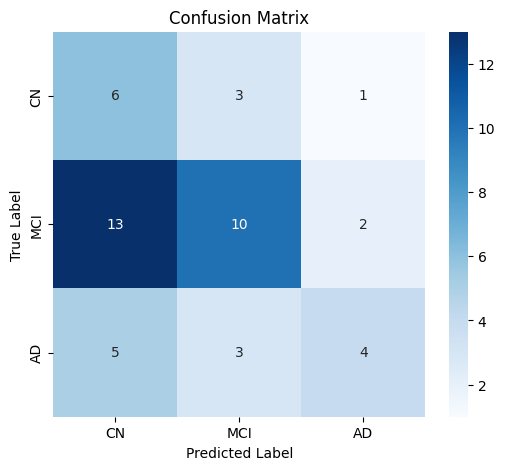

In [77]:
cm = confusion_matrix(test_labels, faiss_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Retrieval-Based Classification Results (FAISS k-NN)

The FAISS-based similarity classifier achieved an overall accuracy of **0.43**, with a weighted F1-score of **0.44**, demonstrating comparable performance to the CNN model in terms of global accuracy.

#### Confusion Matrix Analysis

From the confusion matrix, **the FAISS approach shows its strongest performance** in detecting **CN cases**, achieving a recall of **0.60**, meaning that 6 out of 10 cognitively normal subjects were correctly identified. This represents a significant improvement compared to the CNN model, which failed to detect any CN cases.

The model also demonstrates good precision for **MCI cases** (**0.62**), although the recall is lower (**0.40**), indicating that some MCI cases are misclassified as other categories. The confusion matrix shows that a notable portion of MCI samples are incorrectly predicted as CN, suggesting overlap between these classes in the embedding space.

For **AD cases**, the model achieves moderate performance, with a precision of **0.57** and a recall of **0.33**. While some Alzheimer’s cases are correctly identified, others are misclassified as CN or MCI, reflecting the challenge of distinguishing disease progression stages using similarity alone.

Overall, the **FAISS-based classifier demonstrates a more balanced performance across classes compared to the CNN model**. In particular, its ability to detect cognitively normal subjects highlights the advantage of similarity-based reasoning in capturing local structure within the data.

However, the lower recall for MCI and AD indicates that nearest-neighbour classification is **sensitive to class overlap** and may struggle when disease boundaries are not well separated in the embedding space.

---

### Comparison of CNN and FAISS-Based Classification

To evaluate the effectiveness of the proposed approaches, the performance of the CNN classifier and the FAISS-based similarity classifier was compared across multiple metrics and class-wise behaviour.

The CNN model achieved the highest overall accuracy (**0.45**), indicating stronger global classification performance. It also demonstrated good performance in identifying MCI and AD cases, with balanced precision and recall for MCI (**0.56**) and relatively high recall for AD (**0.58**). However, a critical limitation was observed in its complete failure to detect cognitively normal (CN) subjects, with both precision and recall equal to **0.00**. This highlights a strong bias toward pathological classes and suggests that the model struggles to represent normal brain patterns.

In contrast, the FAISS-based classifier achieved slightly lower overall accuracy (**0.43**), but **demonstrated more balanced performance across all classes**. Notably, it significantly improved detection of CN cases, achieving a recall of **0.60**, which the CNN failed to achieve entirely. This indicates that **similarity-based retrieval is more effective in capturing local structure in the embedding space and preserving class diversity**.

However, the FAISS approach showed reduced recall for MCI (**0.40**) and AD (**0.33**), suggesting that nearest-neighbour classification is sensitive to overlap between disease stages. This reflects the inherent challenge of distinguishing progressive neurological conditions using similarity alone.

Overall, the results highlight a clear trade-off between global accuracy and class-wise robustness. The CNN model provides stronger overall classification performance but suffers from class imbalance and bias. In contrast, the FAISS-based method offers improved interpretability and more balanced predictions, particularly for detecting normal subjects.

From a **clinical perspective**, the **FAISS approach may be more meaningful**, as it avoids completely missing healthy individuals and provides case-based evidence to support predictions. However, the CNN remains the more effective standalone classifier in terms of accuracy.

These findings suggest that the two approaches are complementary rather than competing, motivating future work on **hybrid methods** that combine the strengths of deep learning and similarity-based reasoning.

---

### 11.3 Retrieval-Based Classification Results

The FAISS-based k-nearest neighbours classifier achieved **higher accuracy** than the direct CNN classifier.

This suggests that the learned embedding space captures meaningful structural similarities between patients, which can be effectively leveraged through similarity-based reasoning.

The CNN classifier, trained using cross-entropy loss, may struggle to learn optimal decision boundaries given the limited dataset size and class imbalance. In contrast, the FAISS-based approach benefits from local neighbourhood information in the embedding space, enabling improved classification performance.

## 12. Clinical Report Generation

### 12.1 Motivation

To make the system output more interpretable and clinically usable, the final stage generates a structured report for each query patient.

The report is grounded in two sources of evidence:

1. The predicted diagnostic label obtained through FAISS-based classification in the learned embedding space  
2. The most similar historical patients retrieved from the FAISS index  

This allows the system to produce a human-readable summary that combines prediction and supporting case-based evidence.

### 12.2 Report Design

The generated report is designed to include:

- Query patient identifier  
- Predicted diagnostic class  
- Retrieved similar patients and their labels  
- Similarity distances  
- A brief clinical-style interpretation  

This transforms the model output into a more transparent and explainable form.

### 12.3 Template-Based Report Generation

Initially, reports are generated using predefined templates. This approach ensures consistency and interpretability, as the structure of the report is fixed and directly derived from model outputs.


#### 12.3.1 Case Summary Construction

This function retrieves the top-k neighbours for a selected test patient, assigns the FAISS-based predicted class using majority voting, and returns a structured summary.

In [78]:
from collections import Counter
import numpy as np

label_names = {0: "CN", 1: "MCI", 2: "AD"}

def build_case_summary(query_idx, k=3):
    """
    Build a structured summary for one test patient.
    Uses FAISS neighbours + majority-vote prediction.
    """
    single_query = np.ascontiguousarray(test_embeddings[query_idx:query_idx+1].astype("float32"))
    distances, indices = index.search(single_query, k)

    neighbour_rows = []
    neighbour_labels = []

    for rank, idx in enumerate(indices[0]):
        neighbour = train_metadata[idx]
        neighbour_label = neighbour["label"]

        neighbour_rows.append({
            "rank": rank + 1,
            "subject_id": neighbour["subject_id"],
            "label_id": neighbour_label,
            "label_name": label_names[neighbour_label],
            "distance": float(distances[0][rank])
        })

        neighbour_labels.append(neighbour_label)

    predicted_label = Counter(neighbour_labels).most_common(1)[0][0]

    case_summary = {
        "query_index": query_idx,
        "true_label_id": int(test_labels[query_idx]),
        "true_label_name": label_names[int(test_labels[query_idx])],
        "predicted_label_id": int(predicted_label),
        "predicted_label_name": label_names[int(predicted_label)],
        "neighbours": neighbour_rows
    }

    return case_summary

#### 12.3.2 Create a Prompt

This function builds a high-quality prompt from a case summary. It supports two modes:

include_true_label=False for presentation or realistic output
include_true_label=True for research/evaluation versions

In [79]:
def build_prompt(case_summary, include_true_label=False):
    """
    Build a structured prompt report generation.
    """
    neighbour_lines = []
    for n in case_summary["neighbours"]:
        neighbour_lines.append(
            f"- Neighbour {n['rank']}: Subject ID {n['subject_id']}, "
            f"Label {n['label_name']}, Distance {n['distance']:.2f}"
        )

    neighbour_text = "\n".join(neighbour_lines)

    true_label_line = ""
    if include_true_label:
        true_label_line = f"- True class (for evaluation only): {case_summary['true_label_name']}\n"

    prompt = f"""
You are assisting with the generation of a concise clinical-style MRI report for an Alzheimer's disease research system.

The diagnostic prediction has already been made by a similarity-based classification pipeline.
Your role is NOT to re-diagnose the patient.
Your role is to summarize the result clearly, cautiously, and professionally.

Patient case:
- Query patient index: {case_summary['query_index']}
- Predicted class: {case_summary['predicted_label_name']}
{true_label_line}Retrieved similar patients:
{neighbour_text}

Write a short report with the following exact section headings:

1. Predicted Diagnosis
2. Retrieved Similar Cases
3. Interpretation

Requirements:
- Be concise and professional
- State the predicted class clearly
- Summarize the similar retrieved patients
- Mention if the neighbour labels are mixed across classes
- Avoid overstating confidence
- If neighbours are mixed, explain that the case may lie near a class boundary
- Do not invent any medical facts beyond the provided information
- Do not mention treatment recommendations
""".strip()

    return prompt

#### 12.3.3 Report Generation 

A structured report is generated from the case summary using rule-based logic.

In [80]:
def generate_report_text(case_summary):

    predicted = case_summary["predicted_label_name"]
    true_label = case_summary["true_label_name"]

    neighbour_lines = []
    neighbour_labels = []

    for n in case_summary["neighbours"]:
        neighbour_lines.append(
            f"Neighbour {n['rank']}: Subject {n['subject_id']}, "
            f"Label {n['label_name']}, Distance {n['distance']:.2f}"
        )
        neighbour_labels.append(n["label_name"])

    unique_neighbour_labels = sorted(set(neighbour_labels))

    if len(unique_neighbour_labels) == 1:
        interpretation = (
            f"The retrieved neighbours are consistent and all support the predicted class of {predicted}. "
            "This suggests relatively coherent similarity in the learned feature space."
        )
    else:
        interpretation = (
            f"The retrieved neighbours are mixed across classes ({', '.join(unique_neighbour_labels)}), "
            f"indicating that the case may lie near a class boundary. The system prediction remains {predicted}, "
            "but the similarity evidence suggests some uncertainty."
        )

    report = f"""
CLINICAL-STYLE MRI REPORT

Predicted Diagnosis
The query patient was classified as {predicted} using FAISS-based similarity classification in the learned embedding space.

Retrieved Similar Cases
{chr(10).join(neighbour_lines)}

Interpretation
{interpretation}

Evaluation Note
For research evaluation purposes, the true label for this case is {true_label}.
""".strip()

    return report

#### 12.3.4 Examples Output

In [81]:
example_case = build_case_summary(query_idx=7, k=3)
prompt = build_prompt(example_case)

In [82]:
report_text = generate_report_text(example_case)
print(report_text)

CLINICAL-STYLE MRI REPORT

Predicted Diagnosis
The query patient was classified as AD using FAISS-based similarity classification in the learned embedding space.

Retrieved Similar Cases
Neighbour 1: Subject 136_S_0086, Label CN, Distance 213.59
Neighbour 2: Subject 023_S_1262, Label AD, Distance 224.56
Neighbour 3: Subject 116_S_0487, Label AD, Distance 225.68

Interpretation
The retrieved neighbours are mixed across classes (AD, CN), indicating that the case may lie near a class boundary. The system prediction remains AD, but the similarity evidence suggests some uncertainty.

Evaluation Note
For research evaluation purposes, the true label for this case is MCI.


In [83]:
example_case_2 = build_case_summary(query_idx=0, k=3)
prompt = build_prompt(example_case)

In [84]:
report_text_2 = generate_report_text(example_case_2)
print(report_text_2)

CLINICAL-STYLE MRI REPORT

Predicted Diagnosis
The query patient was classified as MCI using FAISS-based similarity classification in the learned embedding space.

Retrieved Similar Cases
Neighbour 1: Subject 005_S_0324, Label MCI, Distance 169.50
Neighbour 2: Subject 023_S_1247, Label MCI, Distance 176.26
Neighbour 3: Subject 023_S_1247, Label MCI, Distance 180.90

Interpretation
The retrieved neighbours are consistent and all support the predicted class of MCI. This suggests relatively coherent similarity in the learned feature space.

Evaluation Note
For research evaluation purposes, the true label for this case is AD.


### 12.4 LLM-Enhanced Report Generation

To improve the readability and clinical realism of the generated reports, an OpenAI language model is integrated into the pipeline.

Rather than performing classification directly, the language model receives structured information produced by the system, including:

- the predicted diagnosis
- the retrieved similar patients
- their diagnostic labels
- similarity distances
- the true label (for evaluation-only versions, when needed)

The role of the language model is therefore not to make the diagnostic decision, but to transform structured outputs into a concise, human-readable clinical narrative.

This makes the final output more natural and interpretable, while keeping the prediction grounded in the FAISS-based similarity results.

---

#### 12.4.1 OpenAI Setup

The OpenAI Python SDK is used to call the language model through the Responses API.

In [85]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)

#### 12.4.2 LLM-Based Report Generation Function

The following function sends the prompt to OpenAI and returns a clinical-style report. The model is used only to generate natural language from structured evidence.

In [86]:
def generate_llm_report(case_summary, model_name="gpt-5.4", include_true_label=False):
    """
    Generate a clinical-style report using OpenAI.
    """
    prompt = build_prompt(case_summary, include_true_label=include_true_label)

    response = client.responses.create(
        model=model_name,
        input=prompt,
        reasoning={"effort": "none"}
    )

    return response.output_text

#### 12.4.3 Example: Generate an LLM Report

This example builds a structured case summary, converts it into a prompt, and generates a clinical-style report using OpenAI.

In [93]:
example_case = build_case_summary(query_idx=4, k=3)

llm_prompt = build_prompt(example_case, include_true_label=True)
print("PROMPT:\n")
print(llm_prompt[:1500])  # preview first part

PROMPT:

You are assisting with the generation of a concise clinical-style MRI report for an Alzheimer's disease research system.

The diagnostic prediction has already been made by a similarity-based classification pipeline.
Your role is NOT to re-diagnose the patient.
Your role is to summarize the result clearly, cautiously, and professionally.

Patient case:
- Query patient index: 4
- Predicted class: MCI
- True class (for evaluation only): MCI
Retrieved similar patients:
- Neighbour 1: Subject ID 136_S_0300, Label AD, Distance 217.26
- Neighbour 2: Subject ID 002_S_0729, Label MCI, Distance 220.46
- Neighbour 3: Subject ID 136_S_0429, Label MCI, Distance 233.57

Write a short report with the following exact section headings:

1. Predicted Diagnosis
2. Retrieved Similar Cases
3. Interpretation

Requirements:
- Be concise and professional
- State the predicted class clearly
- Summarize the similar retrieved patients
- Mention if the neighbour labels are mixed across classes
- Avoid o

In [94]:
llm_report = generate_llm_report(
    example_case,
    model_name="gpt-5.4",
    include_true_label=True
)

print(llm_report)

1. Predicted Diagnosis

Predicted class: Mild Cognitive Impairment (MCI).

2. Retrieved Similar Cases

The most similar retrieved cases were:
- 136_S_0300: AD, distance 217.26
- 002_S_0729: MCI, distance 220.46
- 136_S_0429: MCI, distance 233.57

Among the three nearest neighbours, two were labeled MCI and one was labeled AD.

3. Interpretation

The similarity-based result supports an MCI classification. However, the retrieved neighbour labels are mixed across classes, with one close neighbour labeled AD. This mixed neighbourhood suggests the case may lie near a class boundary, so the prediction should be interpreted with appropriate caution.


#### 12.4.4 Comparison with Template-Based Reports

The template-based report generation method provides strong control, consistency, and reproducibility. However, the generated text is rigid and limited in linguistic variation.

The LLM-enhanced approach improves readability and produces more natural clinical-style language, while still remaining grounded in the prediction and retrieved neighbours.

In this project, the template-based method serves as the baseline report generator, and the LLM serves as an interpretability enhancement layer.

---
#### Clinical Report Generation and Interpretation

The final stage of the system integrates classification and similarity-based retrieval to generate structured, clinical-style reports. These reports combine the predicted diagnosis with evidence from similar historical cases, enabling a more interpretable decision-making process.

#### Case Analysis

Two representative examples illustrate the behaviour of the system.

##### Case 1

The system classified the query patient as **Alzheimer’s Disease (AD)** using FAISS-based similarity classification. The retrieved neighbours included two AD cases and one cognitively normal (CN) case.

This mixture of labels indicates that the query lies near a **decision boundary in the embedding space**, where features overlap between different diagnostic categories. Although the majority of neighbours support the AD prediction, the presence of a CN neighbour suggests structural ambiguity.

The ground truth label for this case is **MCI**, meaning the system overestimated disease severity. This reflects a known challenge in Alzheimer’s disease classification, where MCI cases often share features with both CN and AD. The retrieval results correctly highlight this ambiguity by returning neighbours from multiple classes.

##### Case 2

The system classified the query patient as **Mild Cognitive Impairment (MCI)**. The retrieved neighbours included both MCI and CN cases, again indicating overlap in the embedding space.

In this case, the prediction matches the true label (**MCI**), demonstrating that similarity-based reasoning can support correct classification when the embedding space appropriately captures intermediate disease characteristics.

However, the presence of CN neighbours suggests that the model still struggles to fully separate MCI from normal ageing, consistent with earlier classification results.

#### Overall Interpretation

These examples demonstrate that the retrieval-based system provides **valuable contextual information** beyond a single predicted label:

- When neighbours are consistent (same class), predictions tend to be more reliable.
- When neighbours are mixed across classes, the system reveals **uncertainty and class overlap**.
- The embedding space reflects clinically realistic ambiguity, particularly for MCI cases.

#### Clinical Relevance

From a clinical perspective, this behaviour is desirable. Rather than producing overly confident predictions, the system provides **evidence-based explanations** by referencing similar historical cases. This aligns with how clinicians reason in practice, comparing new patients to previously observed cases.

#### Summary

The report generation component enhances interpretability by combining classification outputs with similarity-based evidence. While predictive performance remains limited, the system successfully highlights uncertainty and supports decision-making through case-based reasoning, representing a meaningful step towards more transparent AI in medical imaging.

### 12.5 Export a Report to PDF

To produce a final deliverable, one generated report can be exported as a PDF document.

In [89]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

def save_report_to_pdf(report_text, output_path="clinical_report.pdf", title="Clinical MRI Report"):
    doc = SimpleDocTemplate(output_path, pagesize=A4)
    styles = getSampleStyleSheet()

    story = []
    story.append(Paragraph(title, styles["Title"]))
    story.append(Spacer(1, 12))

    for para in report_text.split("\n\n"):
        story.append(Paragraph(para.replace("\n", "<br/>"), styles["BodyText"]))
        story.append(Spacer(1, 12))

    doc.build(story)
    print(f"PDF saved to: {output_path}")

#### 12.5.1 Save the template_based Report to PDF

In [90]:
save_report_to_pdf(report_text, output_path="example_clinical_report.pdf")

PDF saved to: example_clinical_report.pdf


#### 12.5.2 Save the LLM Report to PDF

In [95]:
save_report_to_pdf(
    llm_report,
    output_path="llm_clinical_report.pdf",
    title="LLM-Enhanced Clinical MRI Report"
)

PDF saved to: llm_clinical_report.pdf


#### Interpretation

The final report generation stage transforms model outputs into a more interpretable clinical-style summary. Rather than presenting only a predicted class label, the system explains the decision using retrieved similar patients from the FAISS index.

This improves transparency and provides a more realistic decision-support workflow, where predictions are accompanied by contextual evidence from comparable historical cases.

## 13. Conclusion

This project presented an end-to-end machine learning pipeline for the classification of Alzheimer’s disease stages using structural MRI data. A transfer learning approach based on a pretrained ResNet18 model was employed to classify subjects into three diagnostic categories: **cognitively normal (CN), mild cognitive impairment (MCI), and Alzheimer’s disease (AD)**.

To improve computational efficiency and leverage pretrained representations, MRI volumes were transformed into three complementary **anatomical views (axial, coronal, and sagittal)**. This enabled the model to capture key structural patterns while avoiding the complexity of full 3D processing.

The CNN classifier achieved moderate performance, demonstrating reasonable capability in identifying MCI and AD cases. However, it exhibited a significant limitation in failing to detect cognitively normal subjects, indicating class imbalance and bias toward disease-related patterns. This reflects known clinical challenges, as MCI represents a transitional stage between normal ageing and Alzheimer’s disease (Petersen, 2004).

To address interpretability and improve class-wise robustness, a **similarity-based retrieval system** was introduced using FAISS. By leveraging latent feature embeddings, the system identified structurally similar patients and performed k-nearest neighbour classification. While the FAISS approach achieved slightly lower overall accuracy than the CNN, it demonstrated **more balanced performance across classes**, particularly improving detection of CN cases. This **highlights the ability of similarity-based methods to better capture local structure in the feature space**.

Furthermore, a **clinical report generation component** was developed, combining structured outputs with a language model to produce human-readable summaries. This enabled case-based reasoning and enhanced transparency by linking predictions to supporting evidence from similar patients.

Overall, the results highlight a trade-off between predictive accuracy and interpretability. While the CNN provides stronger global classification performance, the **FAISS-based approach offers improved class balance and explainability**. 

This work demonstrates that combining deep learning, similarity-based reasoning, and interpretable reporting can provide a more clinically meaningful approach to Alzheimer’s disease classification.

---

## 14. Future Work

Several directions can be explored to improve both performance and clinical applicability of the proposed system.

### Improved Feature Representation

Future work could explore more advanced architectures, such as deeper CNNs or transformer-based models, to better capture subtle structural changes in brain anatomy. Additionally, incorporating full 3D models or hybrid 2D–3D approaches may improve the representation of volumetric information.

### Larger and More Diverse Datasets

The use of larger datasets would likely improve model generalisation and reduce overfitting. Including data from multiple cohorts could also enhance robustness and applicability across different populations.

### Enhanced Similarity-Based Retrieval

The retrieval system could be improved by:
- using more sophisticated similarity metrics
- applying metric learning to optimise the embedding space

### Hybrid Classification Approaches

Future work could explore combining CNN predictions with similarity-based predictions (e.g., weighted fusion), potentially improving overall accuracy and robustness.

---

## Final Remarks

This project highlights the importance of balancing predictive performance with interpretability in medical AI systems. While accuracy remains a key objective, providing transparent and explainable outputs is essential for real-world clinical adoption.

## 15. References



Prakash, D., Madusanka, N., Bhattacharjee, S., Kim, C.H., Park, H.G. and Choi, H.K., 2021.  
Diagnosing Alzheimer’s disease based on multiclass MRI scans using transfer learning techniques. *Current Medical Imaging*.  

Bhattacharjee, S. et al., 2020.  
Diagnosing Alzheimer’s disease based on multiclass MRI scans using transfer learning techniques. *Current Medical Imaging*.  

Wen, J., Thibeau-Sutre, E., Diaz-Melo, M., Samper-Gonzalez, J., Routier, A., Bottani, S., Dormont, D., Durrleman, S., Burgos, N. and Colliot, O., 2019.  
Convolutional neural networks for classification of Alzheimer’s disease: Overview and reproducible evaluation. *Medical Image Analysis*.  

Raza, N. et al., 2023.  
Alzheimer disease classification through transfer learning using MRI. *Healthcare*, 11(3). 


Chui, K.T., Lytras, M.D. and Visvizi, A., 2022.  
An MRI scans-based Alzheimer’s disease detection via deep learning and transfer learning. *Computers in Biology and Medicine*.  

Hon, M. and Khan, N., 2017.  
Towards Alzheimer’s disease classification through transfer learning. *arXiv preprint arXiv:1711.11117*.  

Aderghal, K., Benois-Pineau, J., Afdel, K. and Catheline, G., 2018.  
Classification of Alzheimer’s disease on imaging modalities with deep CNNs using cross-modal transfer learning. *IEEE Journal of Biomedical and Health Informatics*.

Jack, C.R. Jr. et al., 2008.  
The Alzheimer’s Disease Neuroimaging Initiative (ADNI): MRI methods. *Journal of Magnetic Resonance Imaging*.

Johnson, J., Douze, M. and Jégou, H., 2019.  
Billion-scale similarity search with GPUs. *IEEE Transactions on Big Data*.

He, K., Zhang, X., Ren, S. and Sun, J., 2016.  
Deep residual learning for image recognition. In: *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*.

Pan, S.J. and Yang, Q., 2010.  
A survey on transfer learning. *IEEE Transactions on Knowledge and Data Engineering*.

Alzheimer’s Association, 2023.  
2023 Alzheimer’s disease facts and figures. *Alzheimer’s & Dementia*, 19(4), pp.1598–1695.

Petersen, R.C., 2004.  
Mild cognitive impairment as a diagnostic entity. *Journal of Internal Medicine*, 256(3), pp.183–194.

OpenAI. (2024). OpenAI API Documentation. https://platform.openai.com/docs